# Electrode localisation

What Do We Know About Electrode Locations?

In scalp EEG, every electrode sits in a known, standardised position. In iEEG, electrodes are placed individually by a neurosurgeon — which means localisation is both more important and much harder to obtain.

This notebook covers:

1. Why electrode localisation is hard in clinical iEEG
2. What information we *do* have: the `_channels.tsv` file
3. Decoding anatomy from channel names
4. Using channel metadata for bad-channel detection
5. Comparing signals between brain regions

## Why don't we have electrode coordinates?

In research iEEG studies, electrode positions are usually obtained by:
1. Taking a post-implant CT scan
2. Co-registering the CT with a pre-implant MRI
3. Automatically or manually localising each contact in MNI space

This pipeline requires extra software (e.g. Freesurfer, MNE, iELVis), takes hours per patient, and is not always shared alongside the raw data in public datasets.

The dataset we are using does **not** include an `_electrodes.tsv` with 3D coordinates — which is common, especially for clinical datasets. What we do have is a `_channels.tsv`, which contains metadata about each channel: its name, type, and quality status.

As we will see, channel **names** alone encode a surprising amount of anatomical information.

In [ ]:
!pip install mne

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
from itertools import combinations

homepath  = '/content/drive/MyDrive/iEEG_course_UCL'
bids_root = Path(homepath) / 'ds003498'
ieeg_dir  = bids_root / 'sub-02' / 'ses-interictalsleep' / 'ieeg'

raw = mne.io.read_raw_brainvision(
    ieeg_dir / 'sub-02_ses-interictalsleep_run-01_ieeg.vhdr',
    preload=True, verbose=False)

print(f"Loaded {len(raw.ch_names)} channels, {raw.times[-1]:.0f} seconds")

Loaded 64 channels, 300 seconds


## The channels.tsv file

Every BIDS iEEG dataset includes a `_channels.tsv` file with one row per channel. Let's read it and see what we have.

In [ ]:
channels_file = ieeg_dir / 'sub-02_ses-interictalsleep_run-01_channels.tsv'
channels = pd.read_csv(channels_file, sep='\t')

print(f"Columns: {list(channels.columns)}")
print(f"Total channels: {len(channels)}\n")
print(channels.head(10))

Columns: ['name', 'type', 'units', 'low_cutoff', 'high_cutoff', 'description', 'sampling_frequency', 'status', 'status_description']
Total channels: 64

   name  type units  low_cutoff  high_cutoff           description  \
0  AHL1  ECOG     V         0.0       1000.0  Electrocorticography   
1  AHL2  ECOG     V         0.0       1000.0  Electrocorticography   
2  AHL3  ECOG     V         0.0       1000.0  Electrocorticography   
3  AHL4  ECOG     V         0.0       1000.0  Electrocorticography   
4  AHL5  ECOG     V         0.0       1000.0  Electrocorticography   
5  AHL6  ECOG     V         0.0       1000.0  Electrocorticography   
6  AHL7  ECOG     V         0.0       1000.0  Electrocorticography   
7  AHL8  ECOG     V         0.0       1000.0  Electrocorticography   
8  AHR1  ECOG     V         0.0       1000.0  Electrocorticography   
9  AHR2  ECOG     V         0.0       1000.0  Electrocorticography   

   sampling_frequency status  status_description  
0              2000.0   g

In [ ]:
# Channel quality and type summary
print("Status counts:")
print(channels['status'].value_counts())
print("\nChannel type counts:")
print(channels['type'].value_counts())

Status counts:
status
good    64
Name: count, dtype: int64

Channel type counts:
type
ECOG    64
Name: count, dtype: int64


## Using channel status for bad-channel detection

In Notebook 2, we detected bad channels using signal variance — a reasonable heuristic, but a blunt instrument. The `_channels.tsv` `status` column is filled in by the clinical team or dataset curators, marking channels that were known to be noisy or broken at the time of recording.

This is more reliable than any automated approach because it can incorporate information we cannot compute from the signal alone — for example, an electrode outside the brain, or a known hardware fault. We should always use this information first.

In [ ]:
# Mark bad channels from the status column
bad_from_tsv = channels[channels['status'] != 'good']['name'].tolist()
print(f"Bad channels from channels.tsv: {bad_from_tsv}")

raw.info['bads'] = bad_from_tsv

good_chs = [ch for ch in raw.ch_names if ch not in raw.info['bads']]
print(f"Good channels remaining: {len(good_chs)}")

Bad channels from channels.tsv: []
Good channels remaining: 64


## Decoding anatomy from channel names

Without 3D coordinates, the channel name is often our best anatomical clue. iEEG channel names follow a consistent convention: a **prefix identifying the electrode shaft**, followed by a **number identifying the contact** on that shaft.

For example, `AHL1` through `AHL8` are contacts 1–8 on shaft `AHL`. The shaft label is chosen by the surgical team and encodes the target brain region and hemisphere:

| Prefix example | Likely meaning |
|---|---|
| `AHL` | Amygdala-Hippocampus Left |
| `AHR` | Amygdala-Hippocampus Right |
| `AL` | Amygdala Left |
| `HL` / `HR` | Hippocampus Left / Right |
| `FL` / `FR` | Frontal Left / Right |
| `TL` / `TR` | Temporal Left / Right |

These are conventions, not standards — always check the dataset paper. But even without documentation, extracting the shaft prefix gives us a useful anatomical proxy.

In [ ]:
# Extract shaft prefix: letters before the trailing digit(s)
channels['shaft'] = channels['name'].apply(lambda n: re.sub(r'\d+$', '', n))

print("Electrode shafts and contacts:")
for shaft, grp in channels.groupby('shaft'):
    contacts = grp['name'].tolist()
    print(f"  {shaft:6s}  ({len(contacts)} contacts): {contacts}")

Electrode shafts and contacts:
  AHL     (8 contacts): ['AHL1', 'AHL2', 'AHL3', 'AHL4', 'AHL5', 'AHL6', 'AHL7', 'AHL8']
  AHR     (8 contacts): ['AHR1', 'AHR2', 'AHR3', 'AHR4', 'AHR5', 'AHR6', 'AHR7', 'AHR8']
  AL      (8 contacts): ['AL1', 'AL2', 'AL3', 'AL4', 'AL5', 'AL6', 'AL7', 'AL8']
  AR      (8 contacts): ['AR1', 'AR2', 'AR3', 'AR4', 'AR5', 'AR6', 'AR7', 'AR8']
  ECL     (8 contacts): ['ECL1', 'ECL2', 'ECL3', 'ECL4', 'ECL5', 'ECL6', 'ECL7', 'ECL8']
  ECR     (8 contacts): ['ECR1', 'ECR2', 'ECR3', 'ECR4', 'ECR5', 'ECR6', 'ECR7', 'ECR8']
  PHL     (8 contacts): ['PHL1', 'PHL2', 'PHL3', 'PHL4', 'PHL5', 'PHL6', 'PHL7', 'PHL8']
  PHR     (8 contacts): ['PHR1', 'PHR2', 'PHR3', 'PHR4', 'PHR5', 'PHR6', 'PHR7', 'PHR8']


In [ ]:
# Infer hemisphere and rough region from the shaft label
def parse_shaft(shaft):
    s = shaft.upper()
    hemisphere = 'Right' if s.endswith('R') else 'Left' if s.endswith('L') else 'Unknown'
    if   'AH' in s:                  region = 'Amygdala-Hippocampus'
    elif 'A'  in s and 'H' not in s: region = 'Amygdala'
    elif 'H'  in s:                  region = 'Hippocampus'
    elif 'F'  in s:                  region = 'Frontal'
    elif 'T'  in s:                  region = 'Temporal'
    elif 'P'  in s:                  region = 'Parietal'
    else:                            region = 'Unknown'
    return region, hemisphere

channels[['region', 'hemisphere']] = channels['shaft'].apply(
    lambda s: pd.Series(parse_shaft(s)))

# Summary: good channels per region
summary = (channels[channels['status'] == 'good']
           .groupby(['region', 'hemisphere'])
           .size()
           .reset_index(name='n_channels'))
print(summary.to_string(index=False))

              region hemisphere  n_channels
            Amygdala       Left           8
            Amygdala      Right           8
Amygdala-Hippocampus       Left           8
Amygdala-Hippocampus      Right           8
         Hippocampus       Left           8
         Hippocampus      Right           8
             Unknown       Left           8
             Unknown      Right           8


## Comparing signals between brain regions

Now that we have region labels, we can do something genuinely interesting: compare iEEG signals from different brain regions. This is one of the things iEEG is uniquely good at — simultaneous recording from deep structures (hippocampus, amygdala) that are completely inaccessible to scalp EEG.

Let's compare the left vs right amygdala-hippocampus.

In [ ]:
# Pick one representative good channel from left and right AH
left_chs  = channels[(channels['region'] == 'Amygdala-Hippocampus') &
                      (channels['hemisphere'] == 'Left') &
                      (channels['status'] == 'good')]['name'].tolist()
right_chs = channels[(channels['region'] == 'Amygdala-Hippocampus') &
                      (channels['hemisphere'] == 'Right') &
                      (channels['status'] == 'good')]['name'].tolist()

# Use a middle contact on each shaft — less likely to be at the grey/white boundary
ch_left  = left_chs[len(left_chs) // 2]
ch_right = right_chs[len(right_chs) // 2]
print(f"Comparing: {ch_left} (left)  vs  {ch_right} (right)")

Comparing: AHL5 (left)  vs  AHR5 (right)


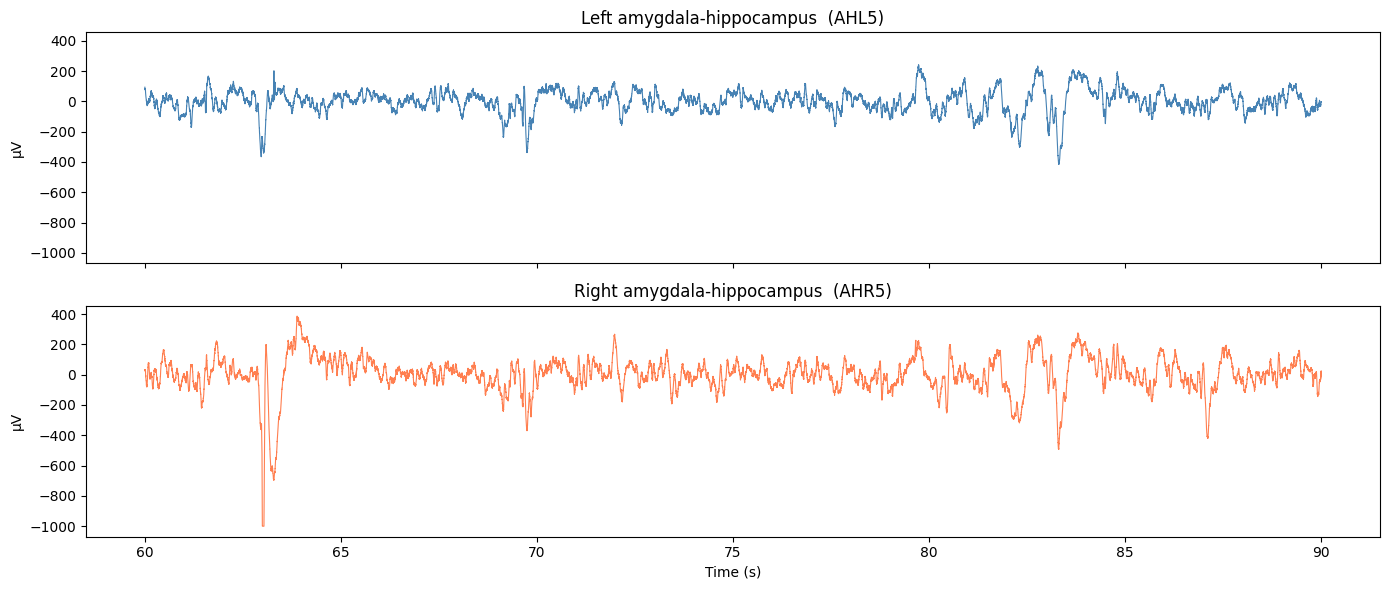

Do the two hemispheres look similar or different?
Large shared slow waves suggest bilateral synchrony; independent patterns suggest local activity.


In [ ]:
T_START, T_END = 60, 90
times = raw.times
mask  = (times >= T_START) & (times <= T_END)

sig_left  = raw.get_data(picks=[ch_left])[0]  * 1e6
sig_right = raw.get_data(picks=[ch_right])[0] * 1e6

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, sharey=True)

axes[0].plot(times[mask], sig_left[mask],  color='steelblue', lw=0.8)
axes[0].set_title(f'Left amygdala-hippocampus  ({ch_left})')
axes[0].set_ylabel('µV')

axes[1].plot(times[mask], sig_right[mask], color='coral', lw=0.8)
axes[1].set_title(f'Right amygdala-hippocampus  ({ch_right})')
axes[1].set_ylabel('µV')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

print("Do the two hemispheres look similar or different?")
print("Large shared slow waves suggest bilateral synchrony; independent patterns suggest local activity.")

## Correlation within vs between regions

We can make this more systematic. Without coordinates, we cannot compute physical distances — but we can classify each pair of channels by their relationship:

- **Same shaft**: contacts are physically adjacent (~3.5 mm apart)
- **Same region, opposite hemisphere**: same target structure, but on the other side of the brain
- **Different regions**: independent anatomical targets

We expect correlations to decrease in that order.

In [ ]:
# 60 seconds of data for all good channels
data_60s = raw.get_data(picks=good_chs, tmin=60, tmax=120) * 1e6
ch_info  = channels.set_index('name')[['shaft', 'region', 'hemisphere']]

same_shaft_corrs, same_region_corrs, diff_region_corrs = [], [], []

for i, j in combinations(range(len(good_chs)), 2):
    ch_i, ch_j = good_chs[i], good_chs[j]
    if ch_i not in ch_info.index or ch_j not in ch_info.index:
        continue
    corr = np.corrcoef(data_60s[i], data_60s[j])[0, 1]
    if ch_info.loc[ch_i, 'shaft'] == ch_info.loc[ch_j, 'shaft']:
        same_shaft_corrs.append(corr)
    elif ch_info.loc[ch_i, 'region'] == ch_info.loc[ch_j, 'region']:
        same_region_corrs.append(corr)
    else:
        diff_region_corrs.append(corr)

for label, corrs in [('Same shaft   ', same_shaft_corrs),
                      ('Same region  ', same_region_corrs),
                      ('Diff region  ', diff_region_corrs)]:
    print(f"{label}  n={len(corrs):4d}  mean r = {np.mean(corrs):.3f}")

Same shaft     n= 224  mean r = 0.680
Same region    n= 256  mean r = 0.481
Diff region    n=1536  mean r = 0.555


/tmp/ipykernel_30610/2074287459.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([same_shaft_corrs, same_region_corrs, diff_region_corrs],


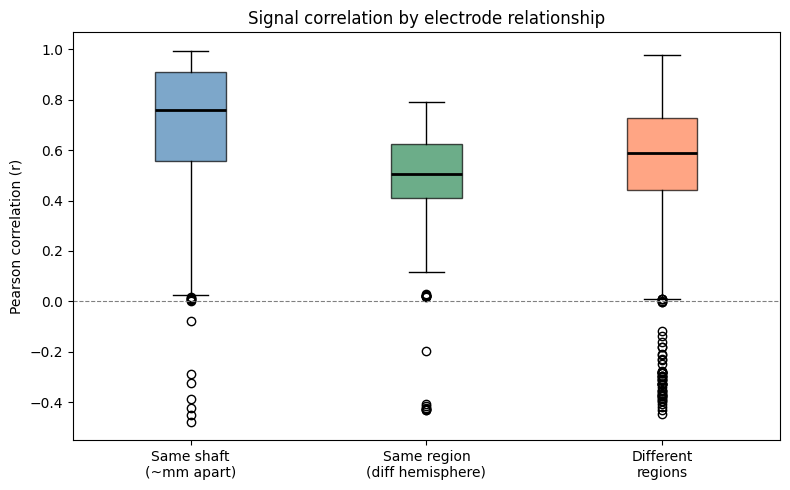

Same-shaft contacts are highly correlated — they record the same local neural population.
Cross-region contacts are much less correlated — they reflect independent activity.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.boxplot([same_shaft_corrs, same_region_corrs, diff_region_corrs],
                labels=['Same shaft\n(~mm apart)', 'Same region\n(diff hemisphere)', 'Different\nregions'],
                patch_artist=True,
                medianprops=dict(color='black', lw=2))

for patch, color in zip(bp['boxes'], ['steelblue', 'seagreen', 'coral']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.set_ylabel('Pearson correlation (r)')
ax.set_title('Signal correlation by electrode relationship')
plt.tight_layout()
plt.show()

print("Same-shaft contacts are highly correlated — they record the same local neural population.")
print("Cross-region contacts are much less correlated — they reflect independent activity.")

## A note on electrode types in this dataset

The `type` column labels all channels as `ECOG`. This is worth clarifying:

| Term | Meaning |
|---|---|
| **ECoG** (grid) | Array laid flat *on the brain surface*. Covers a patch of cortex. |
| **SEEG** (depth) | Thin probe inserted *through* the brain. Contacts spaced along the shaft. |
| **iEEG** | Umbrella term for both — any electrode inside the skull. |

Some datasets (including this one) use `ECOG` loosely as a synonym for iEEG. The 8-contact shaft structure in our channel names (`AHL1`–`AHL8`) strongly suggests these are **SEEG depth electrodes**, not surface grids. Always read the dataset paper alongside the data.

The practical consequence: SEEG contacts sample **deep structures** (hippocampus, amygdala, thalamus) unreachable by surface ECoG or scalp EEG. Contacts 1 and 2 on a shaft are ~3.5 mm apart; contacts 1 and 8 are ~25 mm apart and may sit in entirely different brain regions.

## Summary

We don't have 3D electrode coordinates for this dataset — which is common in clinical iEEG. What we *do* have is still quite useful:

- **`_channels.tsv` status column**: the most reliable source for bad-channel marking — use it before any automated approach
- **Channel name conventions**: shaft prefixes encode target region and hemisphere, giving rough anatomical labels without coordinates
- **Correlation structure**: same-shaft contacts are highly correlated; cross-region contacts are not — confirming the spatial specificity of iEEG even without knowing exact positions

For proper 3D localisation in a real study, you would need post-implant CT + MRI coregistration, processed with tools like MNE, iELVis, or FieldTrip.